In [6]:
import pandas as pd

In [7]:
df=pd.read_csv(r'Salary_dataset.csv')

In [5]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892


In [7]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [8]:
df.shape

(30, 3)

In [9]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [10]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [11]:
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


In [17]:
#remove the unwanted columb
df.drop('Unnamed: 0',axis=1,inplace=True)

In [18]:
df

,YearsExperience,Salary
0,1.2,39344
1,1.4,46206
2,1.6,37732
3,2.1,43526
4,2.3,39892
5,3.0,56643
6,3.1,60151
7,3.3,54446
8,3.3,64446
9,3.8,57190


In [19]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [20]:
#plot the scatter diagram
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Scatter plot of years of experience and salary')

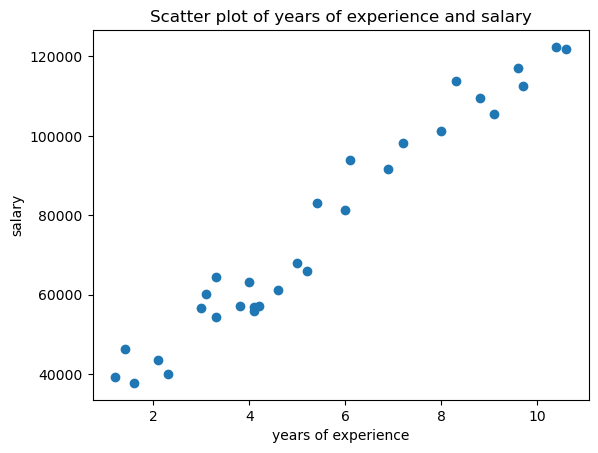

In [21]:
x=df['YearsExperience']
y=df['Salary']
plt.scatter(x,y)
plt.xlabel('years of experience')
plt.ylabel("salary")
plt.title("Scatter plot of years of experience and salary")

In [23]:
#to create linear model
from  sklearn.model_selection import train_test_split

In [33]:
X=df[['YearsExperience']]
y=df['Salary']

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=26,test_size=0.20)

In [63]:
X_train.shape

(24, 1)

In [64]:
X_test.shape

(6, 1)

In [65]:
y_train.shape

(24,)

In [66]:
y_test.shape

(6,)

In [67]:
#import the model and train it
from sklearn.linear_model import LinearRegression

In [68]:
model=LinearRegression()

In [69]:
model.fit(X_train,y_train)

LinearRegression()

In [76]:
model.score(X_train,y_train)

0.9460054870434312

In [77]:
model.score(X_test,y_test)

0.9835849730044817

In [78]:
y_pred=model.predict(X_train)
y_valestpred=model.predict(X_test)

Text(0, 0.5, 'Salary(in thousand)')

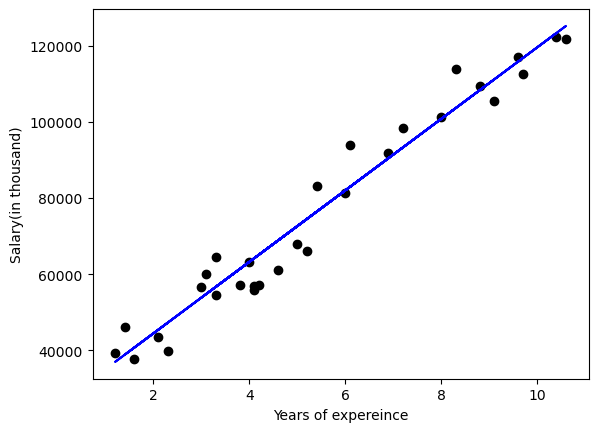

In [79]:
#to plot the bestfit line
plt.scatter(X,y,color='black')
plt.plot(X_train,y_pred,color='blue')
plt.xlabel('Years of expereince')
plt.ylabel('Salary(in thousand)')

In [80]:
model.score(X_test,y_test)

0.9835849730044817

In [81]:
 model.predict(X_train)

array([100807.32890847, 125231.5020826 ,  53837.76511207,  90474.02487326,
        56655.93893985,  64171.06914728, 111140.63294368,  56655.93893985,
        82019.50338991,  63231.67787135,  72625.59063063,  68868.02552692,
        76383.15573434, 103625.50273626,  40686.28724907,  47262.02618057,
        36928.72214536,  65110.4604232 ,  82958.89466584, 123352.71953075,
        38807.50469722,  74504.37318249,  54777.156388  ,  93292.19870105])

In [83]:
model.predict(X_test)

array([115837.58932332,  45383.24362871, 116776.98059925,  64171.06914728,
       108322.4591159 ,  61352.89531949])

In [87]:
#create a dataframe of actual and predicted salary
y_test

26    116970
3      43526
27    112636
12     56958
24    109432
9      57190
Name: Salary, dtype: int64

In [89]:
y_valestpred

array([115837.58932332,  45383.24362871, 116776.98059925,  64171.06914728,
       108322.4591159 ,  61352.89531949])

In [97]:
DF1=pd.DataFrame({'Actual Salary':y_test,'predicted salary':y_valestpred})

In [98]:
#SEND this file to your boss
DF1

,Actual Salary,predicted salary
26,116970,115837.589323
3,43526,45383.243629
27,112636,116776.980599
12,56958,64171.069147
24,109432,108322.459116
9,57190,61352.895319


In [100]:
df.to_csv('DF1')

In [101]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_pred = model.predict(X_test)

print("Intercept (b0):", model.intercept_)
print("Coefficient (b1):", model.coef_[0])

print("\nEvaluation Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 score:", r2_score(y_test, y_pred))

Intercept (b0): 25656.02683422494
Coefficient (b1): 9393.912759280784

Evaluation Metrics:
MAE: 3269.356709252477
MSE: 15411428.84972412
RMSE: 3925.739274292693
R^2 score: 0.9835849730044817
